# Gabor filtering of a CT slice

This notebook uses packages already listed in the project requirements. It uses
`skimage.filters.gabor` instead of OpenCV, locates the repository data folder
robustly, and memory-maps the TIFF so the complete 1 GB volume is not loaded into
RAM.


In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tifffile
from skimage.filters import gabor, gabor_kernel


In [7]:
def find_repository_root() -> Path:
    candidates = (Path.cwd(), *Path.cwd().parents)
    for candidate in candidates:
        if (candidate / "data").is_dir() and (candidate / "requirements.txt").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the repository root. Start Jupyter from this repository."
    )


ROOT = find_repository_root()
TIFF_PATH = ROOT / "data" / "9x9x9_octet_lattice" / "9x9x9_octet_lattice.tif"
if not TIFF_PATH.exists():
    raise FileNotFoundError(f"TIFF not found: {TIFF_PATH}")

# Memory mapping keeps the full CT stack on disk and loads slices on demand.
volume = tifffile.memmap(TIFF_PATH)
print(f"TIFF: {TIFF_PATH}")
print(f"Shape: {volume.shape}; dtype: {volume.dtype}")


TIFF: c:\Users\oconn\DSC2026\llnl_data_science_challenge_2026\data\9x9x9_octet_lattice\9x9x9_octet_lattice.tif
Shape: (761, 815, 837); dtype: >u2


## Define and inspect the Gabor kernel

`frequency` is measured in cycles per pixel. `theta` controls orientation,
while `sigma_x` and `sigma_y` control the Gaussian envelope.


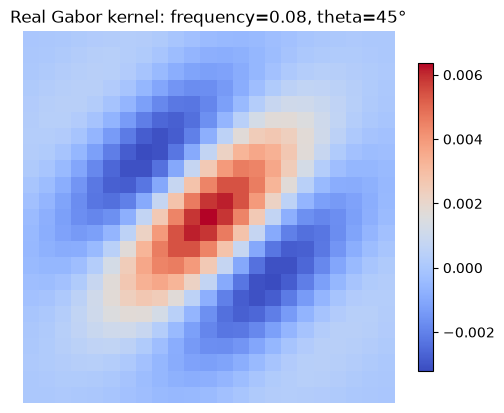

In [8]:
frequency = 0.08
theta = np.pi / 4
sigma_x = 5.0
sigma_y = 5.0

kernel = gabor_kernel(
    frequency=frequency,
    theta=theta,
    sigma_x=sigma_x,
    sigma_y=sigma_y,
)

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(np.real(kernel), cmap="coolwarm")
ax.set_title(
    f"Real Gabor kernel: frequency={frequency:.2f}, "
    f"theta={np.degrees(theta):.0f}°"
)
ax.set_axis_off()
fig.colorbar(image, ax=ax, shrink=0.8)
plt.show()


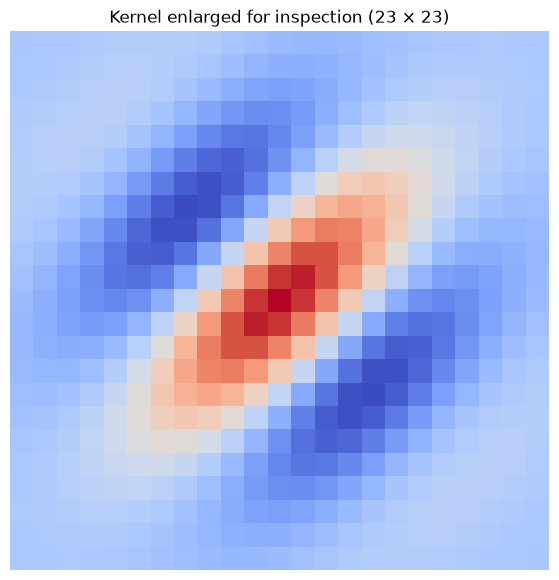

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(np.real(kernel), cmap="coolwarm", interpolation="nearest")
ax.set_title(f"Kernel enlarged for inspection ({kernel.shape[0]} × {kernel.shape[1]})")
ax.set_axis_off()
plt.show()


## Filter one CT slice

The selected slice is normalized using its 1st and 99th intensity percentiles.
The response magnitude combines the real and imaginary Gabor responses and is
less sensitive to phase than displaying only the real response.


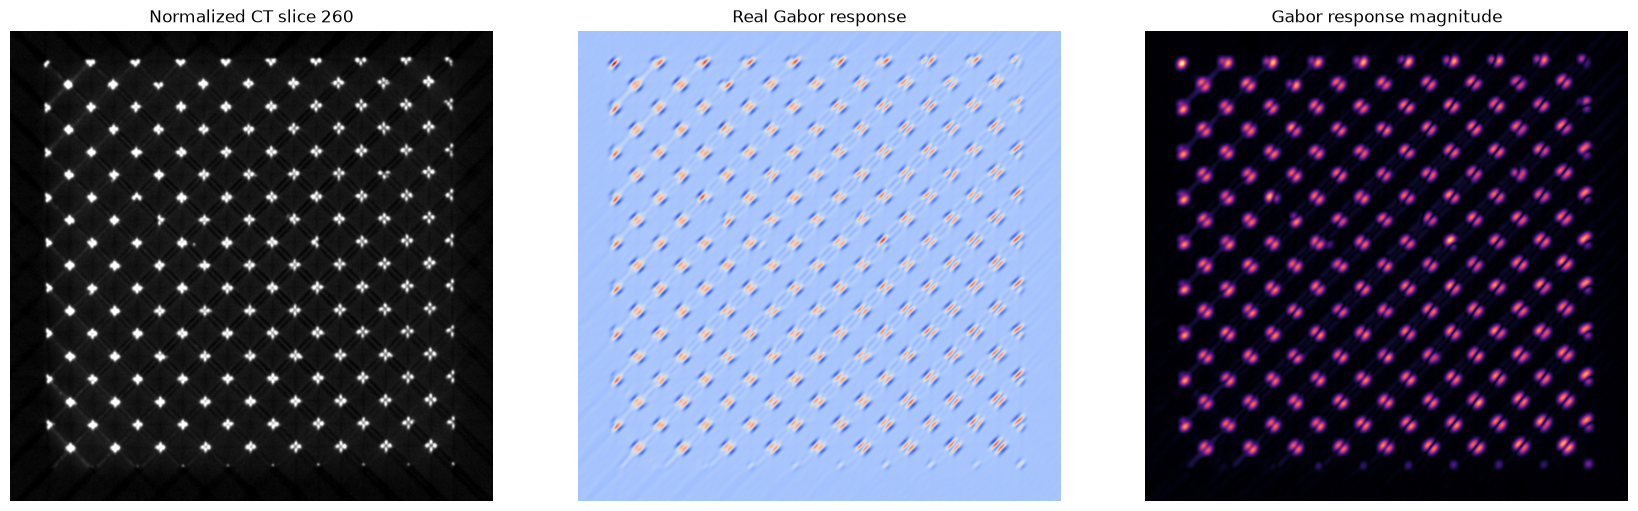

In [10]:
slice_index = min(260, volume.shape[0] - 1)
raw_slice = np.asarray(volume[slice_index], dtype=np.float32)

low, high = np.percentile(raw_slice, [1, 99])
if high <= low:
    raise ValueError(f"Slice {slice_index} has no usable intensity range")
normalized_slice = np.clip((raw_slice - low) / (high - low), 0.0, 1.0)

real_response, imaginary_response = gabor(
    normalized_slice,
    frequency=frequency,
    theta=theta,
    sigma_x=sigma_x,
    sigma_y=sigma_y,
)
response_magnitude = np.hypot(real_response, imaginary_response)

fig, axes = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)
axes[0].imshow(normalized_slice, cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"Normalized CT slice {slice_index}")
axes[1].imshow(real_response, cmap="coolwarm")
axes[1].set_title("Real Gabor response")
axes[2].imshow(response_magnitude, cmap="magma")
axes[2].set_title("Gabor response magnitude")
for axis in axes:
    axis.set_axis_off()
plt.show()


## Parameters to explore

- Change `theta` to detect struts at different orientations.
- Lower `frequency` for wider structures; raise it for finer structures.
- Set different `sigma_x` and `sigma_y` values for an elongated filter.
- Combine the maximum response from several orientations to create an
  orientation-independent strut response.
